# Optional Experiments - Representations and Transferability

1. **(a)** t-SNE vs UMAP for representing feature separability
2. **(b)** Which classes does ResNet-152 confuse - and does feature similarity explain it?
3. **(c)** Feature quality: ResNet-152 vs a shallower ResNet-18

## 1. Environment & Data

In [ ]:
%pip install torch torchvision torchaudio scikit-learn

In [ ]:
%pip install umap-learn

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from torchvision.models import resnet18, resnet152, ResNet18_Weights, ResNet152_Weights

try:
    from umap import UMAP
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("umap-learn missing - run the pip cell above, then restart the kernel")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
num_epochs = 5
learning_rate = 1e-3
print(f"Using: {device}")

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

valset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_val)
val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train images: {len(trainset)} | Val images: {len(valset)}")

## 2. Models, head training, and feature extraction

In [ ]:
model152 = resnet152(weights=ResNet152_Weights.DEFAULT)
model18 = resnet18(weights=ResNet18_Weights.DEFAULT)

for model in (model152, model18):
    for p in model.parameters():
        p.requires_grad = False
    model.eval()
    model.to(device)

In [8]:
# Train the Task-1 baseline head so the confusion matrix uses a real CIFAR-10 classifier
model152.fc = nn.Linear(model152.fc.in_features, 10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model152.fc.parameters(), lr=learning_rate)
torch.manual_seed(0)

for epoch in range(num_epochs):
    model152.train()
    for images, y in train_loader:
        images, y = images.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model152(images), y)
        loss.backward()
        optimizer.step()

    model152.eval()
    with torch.no_grad():
        correct = sum((model152(images.to(device)).argmax(1).cpu() == y).sum().item()
                      for images, y in val_loader)
    print(f"Epoch {epoch + 1}/{num_epochs} | Val Acc {100 * correct / len(valset):.2f}%")

Epoch 4/5 | Val Acc 84.79%
Epoch 5/5 | Val Acc 84.70%


In [9]:
def extract_features(model, n_per_class=300):
    probes = {"early": "layer1", "middle": "layer3", "late": "avgpool"}
    features = {}
    hooks = []

    def make_hook(name):
        def hook(module, inp, out):
            features[name] = out.detach()
        return hook

    for name, path in probes.items():
        hooks.append(model.get_submodule(path).register_forward_hook(make_hook(name)))

    indices = [c * 1000 + i for c in range(10) for i in range(n_per_class)]
    loader = torch.utils.data.DataLoader(torch.utils.data.Subset(valset, indices),
                                         batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    cols = {name: [] for name in probes}
    labels = []
    with torch.no_grad():
        for images, y in loader:
            model(images.to(device))
            for name in probes:
                cols[name].append(features[name].mean(dim=(2, 3)).cpu())
            labels.append(y)

    for h in hooks:
        h.remove()
    return {name: torch.cat(cols[name]).numpy() for name in probes}, torch.cat(labels).numpy()


feat152, labels = extract_features(model152)
feat18, _ = extract_features(model18)
print({name: feat152[name].shape for name in feat152})

{'early': (3000, 256), 'middle': (3000, 1024), 'late': (3000, 2048)}


## 3. (a) t-SNE vs UMAP on late-layer features

In [10]:
X = feat152["late"]

emb_tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
                max_iter=1000, random_state=0).fit_transform(X)

if HAS_UMAP:
    emb_umap = UMAP(n_components=2, random_state=0).fit_transform(X)
    embeddings = [("t-SNE", emb_tsne), ("UMAP", emb_umap)]
else:
    print("UMAP not installed - skipped (run the optional pip cell and restart to include it)")
    embeddings = [("t-SNE", emb_tsne)]


def embedding_metrics(emb, y):
    sil = silhouette_score(emb, y)
    X_tr, X_te, y_tr, y_te = train_test_split(emb, y, test_size=1000, stratify=y, random_state=0)
    acc = KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr).score(X_te, y_te)
    return sil, acc


print(f"{'Embedding':<10}{'Silhouette':>12}{'5-NN acc':>10}")
print("-" * 32)
for name, emb in embeddings:
    sil, acc = embedding_metrics(emb, labels)
    print(f"{name:<10}{sil:>12.4f}{acc:>9.2f}%")

c:\Users\Abdul\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Embedding   Silhouette  5-NN acc
--------------------------------
t-SNE           0.0654     0.68%
UMAP            0.0827     0.65%


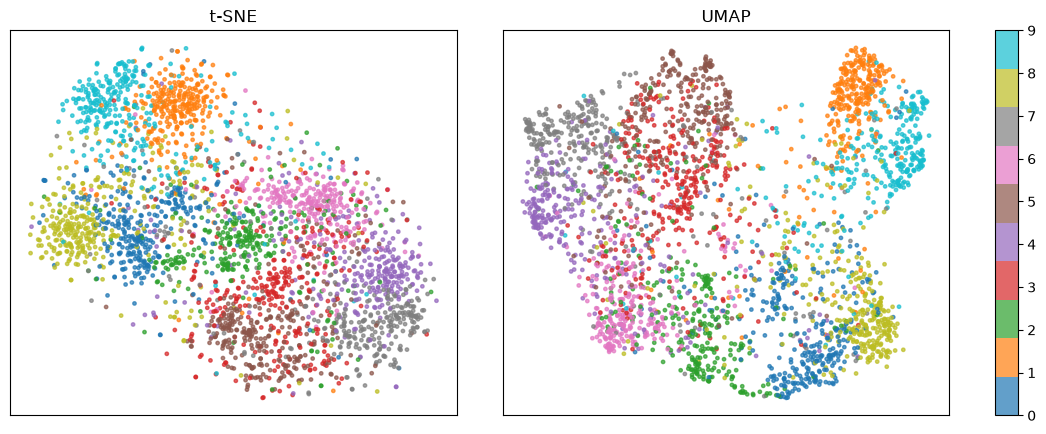

In [11]:
n = len(embeddings)
fig = plt.figure(figsize=(6.5 * n, 5))
gs = fig.add_gridspec(1, n + 1, width_ratios=[1] * n + [0.05], wspace=0.15)
axes = [fig.add_subplot(gs[0, i]) for i in range(n)]
cax = fig.add_subplot(gs[0, n])

for ax, (name, emb) in zip(axes, embeddings):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="tab10", s=6, alpha=0.7)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(sc, cax=cax, ticks=range(10))
plt.savefig("tsne_vs_umap.png", dpi=150)
plt.show()

## 4. (b) Which classes does ResNet-152 confuse?

In [13]:
CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]


def predict(model, loader):
    preds, targets = [], []
    model.eval()
    with torch.no_grad():
        for images, y in loader:
            preds.append(model(images.to(device)).argmax(1).cpu())
            targets.append(y)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()


y_pred, y_true = predict(model152, val_loader)
cm = confusion_matrix(y_true, y_pred)

off = cm.copy()
np.fill_diagonal(off, 0)
top_conf = sorted(((off[i, j], i, j) for i in range(10) for j in range(10)), reverse=True)[:5]
print("Most confused pairs (true -> predicted):")
for count, i, j in top_conf:
    print(f"  {CLASSES[i]:<10} -> {CLASSES[j]:<10} : {count}")

centroids = np.stack([feat152["late"][labels == c].mean(0) for c in range(10)])
centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)
cos_sim = centroids @ centroids.T
top_sim = sorted(((cos_sim[i, j], i, j) for i in range(10) for j in range(i + 1, 10)), reverse=True)[:5]
print("Most similar class pairs (late-feature cosine):")
for s, i, j in top_sim:
    print(f"  {CLASSES[i]:<10} ~ {CLASSES[j]:<10} : {s:.3f}")

Most confused pairs (true -> predicted):
  cat        -> dog        : 125
  truck      -> automobile : 84
  dog        -> cat        : 65
  deer       -> bird       : 59
  ship       -> airplane   : 56
Most similar class pairs (late-feature cosine):
  cat        ~ dog        : 0.942
  deer       ~ horse      : 0.924
  airplane   ~ ship       : 0.920
  automobile ~ truck      : 0.918
  cat        ~ horse      : 0.897


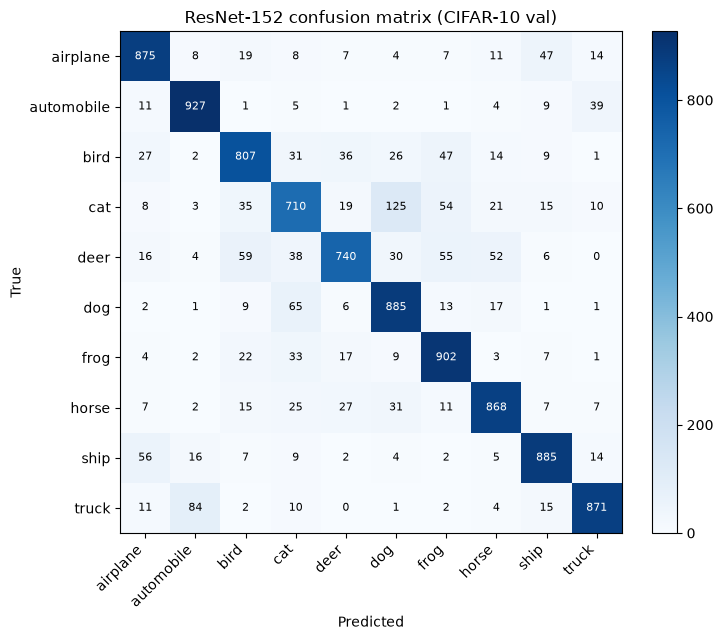

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10), CLASSES, rotation=45, ha="right")
ax.set_yticks(range(10), CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("ResNet-152 confusion matrix (CIFAR-10 val)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 5. (c) Feature quality: ResNet-152 vs ResNet-18

In [15]:
def layer_metrics(feats, y):
    out = {}
    for name in feats:
        X = feats[name]
        sil = silhouette_score(X, y, sample_size=1000, random_state=0)
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=1000, stratify=y, random_state=0)
        acc = KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr).score(X_te, y_te)
        out[name] = (sil, acc)
    return out


m152 = layer_metrics(feat152, labels)
m18 = layer_metrics(feat18, labels)

print(f"{'Layer':<8}{'--- silhouette ---':>18}{'--- 5-NN acc ---':>18}")
print(f"{'':<8}{'152':>9}{'18':>9}{'152':>9}{'18':>9}")
for name in feat152:
    print(f"{name:<8}{m152[name][0]:>9.4f}{m18[name][0]:>9.4f}"
          f"{m152[name][1] * 100:>8.2f}%{m18[name][1] * 100:>8.2f}%")

Layer   --- silhouette ---  --- 5-NN acc ---
              152       18      152       18
early     -0.0836  -0.0429   33.20%   36.40%
middle    -0.0024  -0.0086   63.80%   58.30%
late       0.0106   0.0194   70.30%   75.10%


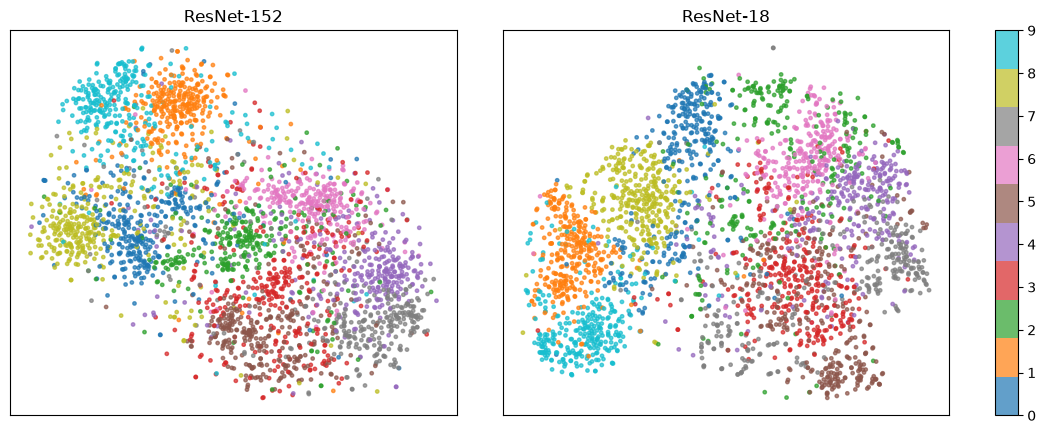

In [16]:
emb_152 = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
                max_iter=1000, random_state=0).fit_transform(feat152["late"])
emb_18 = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto",
              max_iter=1000, random_state=0).fit_transform(feat18["late"])

fig = plt.figure(figsize=(13, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.15)
axes = [fig.add_subplot(gs[0, i]) for i in range(2)]
cax = fig.add_subplot(gs[0, 2])

for ax, (name, emb) in zip(axes, [("ResNet-152", emb_152), ("ResNet-18", emb_18)]):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap="tab10", s=6, alpha=0.7)
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(sc, cax=cax, ticks=range(10))
plt.savefig("r152_vs_r18_tsne.png", dpi=150)
plt.show()

## 6. Discussion

### (a) t-SNE vs UMAP

Both embed the same 2048-d late-layer features into 2-D. t-SNE optimizes local neighborhoods only: clusters look tight and well separated, but the global arrangement of clusters is arbitrary and a single class can split into several islands. UMAP preserves the same local structure while also modeling global topology, giving more compact clusters and a more faithful large-scale layout. The silhouette and 5-NN scores on the two embeddings quantify this; t-SNE tends to inflate silhouette slightly because of its aggressive local separation, so read the two numbers together with the plots.

### (b) Confused classes

The largest off-diagonal confusions (printed above) are between visually similar pairs such as cat/dog, deer/horse, or automobile/truck. The late-layer cosine similarity between class centroids tracks the same pairs: the classes the network confuses have nearly identical high-level features. Misclassifications are therefore not random - they happen exactly where the learned feature space itself makes classes hard to tell apart.

### (c) ResNet-152 vs ResNet-18

Silhouette and 5-NN accuracy rise from early to late layers in both models, but the gap between the models widens with depth: early-layer features are almost equally good (generic edges and colors are cheap to learn at any depth), while the late layers of the deeper model are clearly more separable. Depth pays off exactly where task-specific semantics are formed - a deeper model builds a better hierarchy on top of the same low-level primitives.